# Time series extraction
---

Running this notebook you will:

- Compute and verify the neural-muscular ratio of the organoid from the image
- Save the ratios to a file
- Extract the timeseries for each video recording
- Verify that the threshold used for the boarder segmentation is good

## Mount google drive

Please mount your google drive and find your working folder with the data you uploaded.

In [ ]:
#@markdown ###Step 1. Run this cell to connect your Google Drive to Colab and install packages

#@markdown * Click on the URL.

#@markdown * Sign in your Google Account.

#@markdown * Click on "Files" site on the right. Refresh the site. Your Google Drive folder should now be available here as "drive".

#mounts user's Google Drive to Google Colab.

from google.colab import drive
drive.mount('/content/gdrive')

%cd /content/gdrive/MyDrive/NMO-colab/

!pip install readlif
!pip install ipympl

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/MyDrive/NMO-colab


In [ ]:
#@markdown ###Step 2. Import
#@markdown Execute this cell to import the necessary packages
import os
from pathlib import Path

from google.colab import output
output.enable_custom_widget_manager()

import numpy as np
import pandas as pd
from math import sqrt, ceil, hypot, degrees, atan
%matplotlib inline
%matplotlib widget
from matplotlib import pyplot as plt
from matplotlib.widgets import Slider, Button, RadioButtons
import ipywidgets as ipyw

from readlif.reader import LifFile
from skimage.io import imread, imsave

from scipy.ndimage import binary_fill_holes
from scipy import interpolate
from skimage import feature
from skimage.filters import threshold_otsu, gaussian, threshold_multiotsu
from skimage.transform import rotate, SimilarityTransform
from skimage.morphology import disk, erosion, remove_small_holes, binary_opening, remove_small_objects, opening
from skimage.measure import label, regionprops


In [ ]:
#@markdown ###Step 3.A. Data path Videos
#@markdown ####Write the path to your data (lif video files):

src_filepath = 'videos' #@param {type:"string"}

#@markdown ####And the path of the folder where to save the extracted signals:

dst_filepath = 'extracted_signals' #@param {type:"string"}

def remove_border_points(border_points):
    '''Remove the white pixels on border of image'''
    border_x = list(border_points[0])
    border_y = list(border_points[1])
    i = 0
    remove_ids = []
    for x, y in zip(border_x, border_y):
        if x<2 or x>252 or y<5 or y>252: remove_ids.append(i)
        i+=1
    for i in reversed(remove_ids):
        border_x.pop(i)
        border_y.pop(i)
    return (np.array(border_x), np.array(border_y))

def get_thresh(img_slice0, sigma_smooth=2):
  img_smooth = gaussian(img_slice0, sigma_smooth)
  thresh = threshold_otsu(img_smooth)
  return thresh, np.min(img_smooth), np.max(img_smooth)

def extract_border(img_slice, thresh, sigma_smooth=2, sigma_edge=3):
    '''
    Extract the border from a single frame, by following:
    1. Threshold image using Otsu thresholding
    2. Apply morphological opening and fill any holes in the binary image
    3. Compute edges using the Canny edge Detection algorithm
    4. Remove white pixels from border of image
    6. Return border coordinates and binary image
    '''
    img_smooth = gaussian(img_slice, sigma_smooth)
    image_thresh = img_smooth > thresh
    image_thresh = binary_opening(image_thresh, disk(4))
    image_thresh = remove_small_objects(image_thresh, min_size=400)

    edges = feature.canny(image_thresh, sigma_edge)
    x,y = remove_border_points((np.where(edges)))

    return (x,y), image_thresh

def sort_border(x,y):
    ''' Sort border pixels such that the signal coordinates are continuous'''
    sorted_x = x[np.argsort(x)] # sort x values
    sorted_y = y[np.argsort(y)] # sort y values
    max_dist_x = sorted_x[-1] - sorted_x[0] # compute max distance on x axis
    max_dist_y = sorted_y[-1] - sorted_y[0] # compute max distance on y axis
    # if x changes more than y
    if max_dist_x > max_dist_y: point0 = np.where(x==sorted_x[0])[0][0] # sort (x,y) points according to x
    # else sort (x,y) points according to y
    else: point0 = np.where(y==sorted_y[0])[0][0]

    sorted_ids = np.argsort((x-x[point0])**2+(y-y[point0])**2) # x+y
    x = x[sorted_ids]
    y = y[sorted_ids]
    return (x,y)

def get_border_angle(x , y):
    ''' Compute the angle of the border considering it as a line from first to last point'''
    xl = x[-1] - x[0]
    yl = y[-1] - y[0]
    theta = degrees(atan(xl/yl))
    # if theta is negative and the border is sorted according to x we want to rotate counter-clockwise
    # and by 180+theta to make sure x[0], y[0] moves to the begining of the signal
    if y[0] > y[-1]: theta = 180+theta
    return theta

#@markdown Now execute this cell

In [ ]:
#@markdown ###Step 3.B. Data path N-M Ratio Images
#@markdown ####Write the path to your data (images):

src_filepath_imgs = 'images' #@param {type:"string"}


In [ ]:
#@markdown ###Step 3.C. Select working datasheet
files = [file for file in os.listdir('.') if (file.endswith('.xlsx') or file.endswith('.csv') or file.endswith('.xls'))]
print('Going to write to excel sheet: ', files[0])

#@markdown Execute the cell and if you choose to work on a different file from that displayed **then** select it from the dropdown menu.

wig_ds = ipyw.Dropdown(
    options=files,
    description='datasheet:'
)
display(wig_ds)



Going to write to excel sheet:  Contraction_videos_legend.xlsx


Dropdown(description='datasheet:', options=('Contraction_videos_legend.xlsx', 'Datasheet.xlsx'), value='Contra…

In [ ]:
#@markdown ###Step 4.A. Image file selection
files = [file for file in os.listdir(src_filepath_imgs) if file.endswith('.tif')]
print('Dataset includes ', len(files), ' images')

#@markdown Execute the cell and **then** select the video you wish work on.

wig_img = ipyw.Dropdown(
    options=files,
    description='image:'
)
display(wig_img)

Dataset includes  7  images


Dropdown(description='image:', options=('P1453_a_KOLF_ctrl_d51_O5.tif', 'P1453_a_KOLF_ctrl_d50_O2.tif', 'P1453…

<ipython-input-101-99713d972f03>:57: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig, self.ax = plt.subplots()


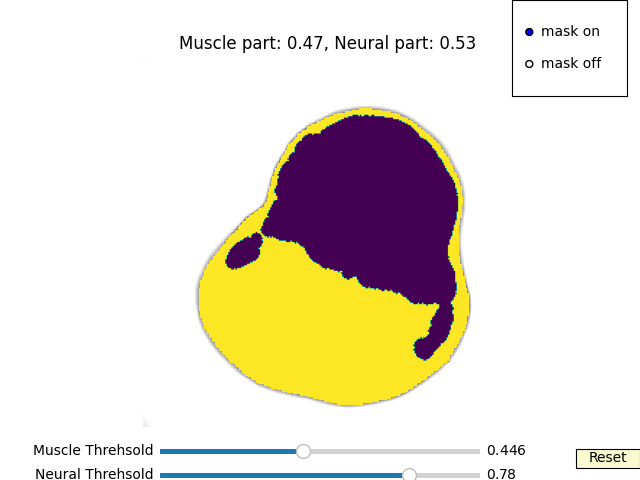

In [ ]:
#@markdown ###Step 4.B. N-M ratio computation

# Get the two threhsolds for the image using multi-otsu thresholding
def get_mutli_otsu_thresholds(img):
  thresholds = threshold_multiotsu(img, classes=3)
  return thresholds

# Apply the threhsolds from the otsu method and generate a mask
def apply_thresholds(img, thresholds):
  mask = np.zeros(img.shape, dtype=np.uint8)
  mask[img<thresholds[1]] = 9 # neural threshold
  mask[img<thresholds[0]] = 4 # muscle threshold
  return mask


# Remove small areas and holes from both neural and muscle parts
def remove_holes_and_objects(mask, min_size=500): #1000
  label_mask = label(mask)
  # removed objects smaller than min_size
  for region in regionprops(label_mask):
      if region.area<min_size:
          mask[label_mask==region.label] = 0

  mask_n = np.zeros_like(mask)
  mask_n[mask==4] = 1
  mask_m = np.zeros_like(mask)
  mask_m[mask==9] = 1
  # fill holes
  mask_n = binary_fill_holes(mask_n)
  mask_n = opening(mask_n, disk(4))
  mask_m = binary_fill_holes(mask_m)
  mask_m = opening(mask_m, disk(4))

  mask[mask_m!=0] = 9
  mask[mask_n!=0] = 4
  return mask

# Compute the ratio of neural and muscle parts on the organoid mask
def compute_nm_ratio(mask):
  n_pix = np.sum(mask==9)
  m_pix = np.sum(mask==4)
  if n_pix==0 and m_pix==0: return 0, 0
  return np.round(n_pix/(n_pix+m_pix), 2), np.round(m_pix/(n_pix+m_pix),2)


class Viewer():
  def __init__(self, img):
    self.img = img
    otsu_thresholds = get_mutli_otsu_thresholds(self.img)
    self.mask = apply_thresholds(self.img, otsu_thresholds)
    self.mask = remove_holes_and_objects(self.mask)
    self.n_ratio, self.m_ratio = compute_nm_ratio(self.mask)
    self.thresh0, self.thresh1 = otsu_thresholds
    fig_title = 'Muscle part: '+str(self.m_ratio)+', Neural part: '+str(self.n_ratio)

    # Setup figure properties and add the image to the plot
    self.fig, self.ax = plt.subplots()
    original_img = self.ax.imshow(self.img, cmap='gray')
    self.ax.set_axis_off()
    self.ax.set_title(fig_title)
    axis_color = 'lightgoldenrodyellow'

    # Define an axes area and draw a slider in it
    thresh0_slider_ax  = self.fig.add_axes([0.25, 0.05, 0.5, 0.02], facecolor=axis_color)
    self.thresh0_slider = Slider(thresh0_slider_ax, 'Muscle Threhsold', 0.0, 1.0, valinit=self.thresh0)
    self.thresh0_slider.on_changed(self.sliders_on_changed)

    # Draw another slider
    threh1_slider_ax = self.fig.add_axes([0.25, 0.0, 0.5, 0.02], facecolor=axis_color)
    self.thresh1_slider = Slider(threh1_slider_ax, 'Neural Threhsold', 0.0, 1.0, valinit=self.thresh1)
    self.thresh1_slider.on_changed(self.sliders_on_changed)

    # Add a button for resetting the parameters
    reset_button_ax = self.fig.add_axes([0.9, 0.025, 0.1, 0.04])
    reset_button = Button(reset_button_ax, 'Reset', color=axis_color, hovercolor='0.975')
    reset_button.on_clicked(self.reset_button_on_clicked)

    # Add a checkbox to switch between views
    radio_ax = self.fig.add_axes([0.8, 0.8, 0.18, 0.2])
    radio_btn = RadioButtons(radio_ax, ('mask on', 'mask off'))
    radio_btn.on_clicked(self.change_view)

    # Overlay the mask on the image
    self.masked_array = np.ma.masked_array(self.mask, ~self.mask.astype(bool))
    self.masked_image = self.ax.imshow(self.masked_array, cmap='viridis')
    plt.show()

  # Define an action for modifying the image when any slider's value changes
  def sliders_on_changed(self, val):
    self.mask = apply_thresholds(self.img, (self.thresh0_slider.val, self.thresh1_slider.val))
    self.mask = remove_holes_and_objects(self.mask)
    self.n_ratio, self.m_ratio = compute_nm_ratio(self.mask)
    self.masked_image.set_array(np.ma.masked_array(self.mask, ~self.mask.astype(bool)))
    self.fig.canvas.draw_idle()
    self.ax.set_title('Muscle part: '+str(self.m_ratio)+', Neural part: '+str(self.n_ratio))

  # Update the threshold values once the reset button has been clicked
  def reset_button_on_clicked(self, mouse_event):
    self.thresh0_slider.reset()
    self.thresh1_slider.reset()

  # Switch between simple image view and overlay with mask view
  def change_view(self, label):
    if label=='mask on':
      self.masked_image.set_array(np.ma.masked_array(self.mask, ~self.mask.astype(bool)))
    else:
      self.masked_image.set_array(np.ma.masked_array(self.img, ~np.zeros(self.img.shape).astype(bool)))
    self.fig.canvas.draw_idle()

  def get_ratios(self):
    return self.n_ratio, self.m_ratio

  def get_mask(self):
    return self.mask

# Read the image selected by the user, compute thresholds, get mask and n-m ratios
filename =  wig_img.value
img = imread(os.path.join(src_filepath_imgs, filename), as_gray=True)
viewer = Viewer(img)

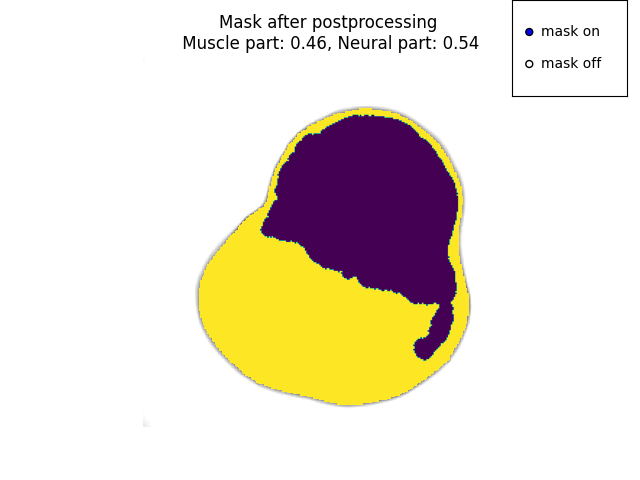

In [ ]:
#@markdown ###Step 4.C.  Apply post processing

# Switch between simple image view and overlay with mask view
def change_view(label):
  if label=='mask on':
    masked_image.set_array(np.ma.masked_array(mask_pp, ~mask_pp.astype(bool)))
  else:
    masked_image.set_array(np.ma.masked_array(img, ~np.zeros(img.shape).astype(bool)))
  fig.canvas.draw_idle()

n_ratio, m_ratio = viewer.get_ratios()
mask = viewer.get_mask()
mask_pp = remove_holes_and_objects(mask, min_size=1000)
n_ratio_pp, m_ratio_pp = compute_nm_ratio(mask_pp)
masked_array = np.ma.masked_array(mask_pp, ~mask_pp.astype(bool))

# Display image and overlay the mask
fig, ax = plt.subplots()
ax.imshow(img, cmap='gray')
masked_image = ax.imshow(masked_array, cmap='viridis')
ax.set_axis_off()
ax.set_title("Mask after postprocessing\n Muscle part: "+str(m_ratio_pp)+", Neural part: "+str(n_ratio_pp))

# Add a checkbox to switch between views
radio_ax = fig.add_axes([0.8, 0.8, 0.18, 0.2])
radio_btn = RadioButtons(radio_ax, ('mask on', 'mask off'))
radio_btn.on_clicked(change_view)

plt.show()

In [ ]:
#@markdown ###Step 4.D. Include Post-processing?
#@markdown Only select the box if the mask below seems better than in the previous step. If so check the box and **then** execute this cell.

post_processing = False # @param {type:"boolean"}



In [ ]:
#@markdown ###Step 4.E.  Write NMO ratios to datasheet

if post_processing:
  n_ratio = n_ratio_pp
  m_ratio = m_ratio_pp

# Open data info file
datafile = wig_ds.value
print('Opening file: ', datafile)
data_info = pd.read_excel(datafile)
df_columns = data_info.columns
# rename column if needed
if 'File_video name' in df_columns: data_info.rename(columns={'File_video name': 'Filename'}, inplace=True)

# If columns don't exist create them
if 'Neural Ratio' not in df_columns: data_info['Neural Ratio'] =  pd.Series(dtype='float')
if 'Muscle Ratio' not in df_columns: data_info['Muscle Ratio'] =  pd.Series(dtype='float')

# Add chosen threshold value to the info file
found_filename = data_info['Filename'].str.contains(Path(filename).stem)
if np.sum(found_filename) == 1:
  print("Adding neural muscle ratios to", Path(filename).stem)
  data_info.loc[found_filename, 'Neural Ratio'] = n_ratio
  data_info.loc[found_filename, 'Muscle Ratio'] = m_ratio
elif np.sum(found_filename) == 0:
  print("Filename ", filename, "not found in datasheet. Creating a new entry. Please fill in the rest of the columns manually.")
  new_row = pd.DataFrame([[Path(filename).stem, np.NaN, np.NaN, np.NaN, np.NaN, np.NaN, n_ratio, m_ratio]], columns=df_columns)
  data_info = pd.concat([data_info, new_row], ignore_index=True)
else:
  print("More than one entries in data sheet found corresponding to the filename ", filename, ".Please delete any wrong entries and run again.")

# And save the result
data_info.to_excel(datafile, index=False)

Opening file:  Datasheet.xlsx


In [ ]:
#@markdown ###Step 5. Video File selection
files = [file for file in os.listdir(src_filepath) if file.endswith('.lif')]
print('Dataset includes ', len(files), ' videos')

#@markdown Execute the cell and **then** select the video you wish work on.

wig = ipyw.Dropdown(
    options=files,
    description='video:'
)
display(wig)


Dataset includes  0  videos


Dropdown(description='video:', options=(), value=None)

In [ ]:
#@markdown ###Step 6.Treshold selection for obtaining organoid border
file_id = files.index(wig.value)
print("Opening file: ", files[file_id])
# read image
img = LifFile(os.path.join(src_filepath, files[file_id]))
img = img.get_image(0)
#@markdown Select the channel you want to work with. If you have only one channel you can set it to 0.
channel = "1" #@param [0, 1]
c = channel
print(f'You selected channel {c}')
img_array = [i for i in img.get_iter_t(c=1, z=0)] #c=0 unique channel, c=1 for second channel
img_array = np.stack(img_array)

thresh, min_int, max_int = get_thresh(img_array[0])
img_gaussian = gaussian(img_array, 2)
thresh = round(thresh,2)
print('Default threshold value is: ', thresh)

Opening file:  230418_P1330_d50_KOLF_O1_a.lif
You selected channel 1
Default threshold value is:  0.61


interactive(children=(FloatSlider(value=0.61, continuous_update=False, description='Threshold:', max=1.0, step…

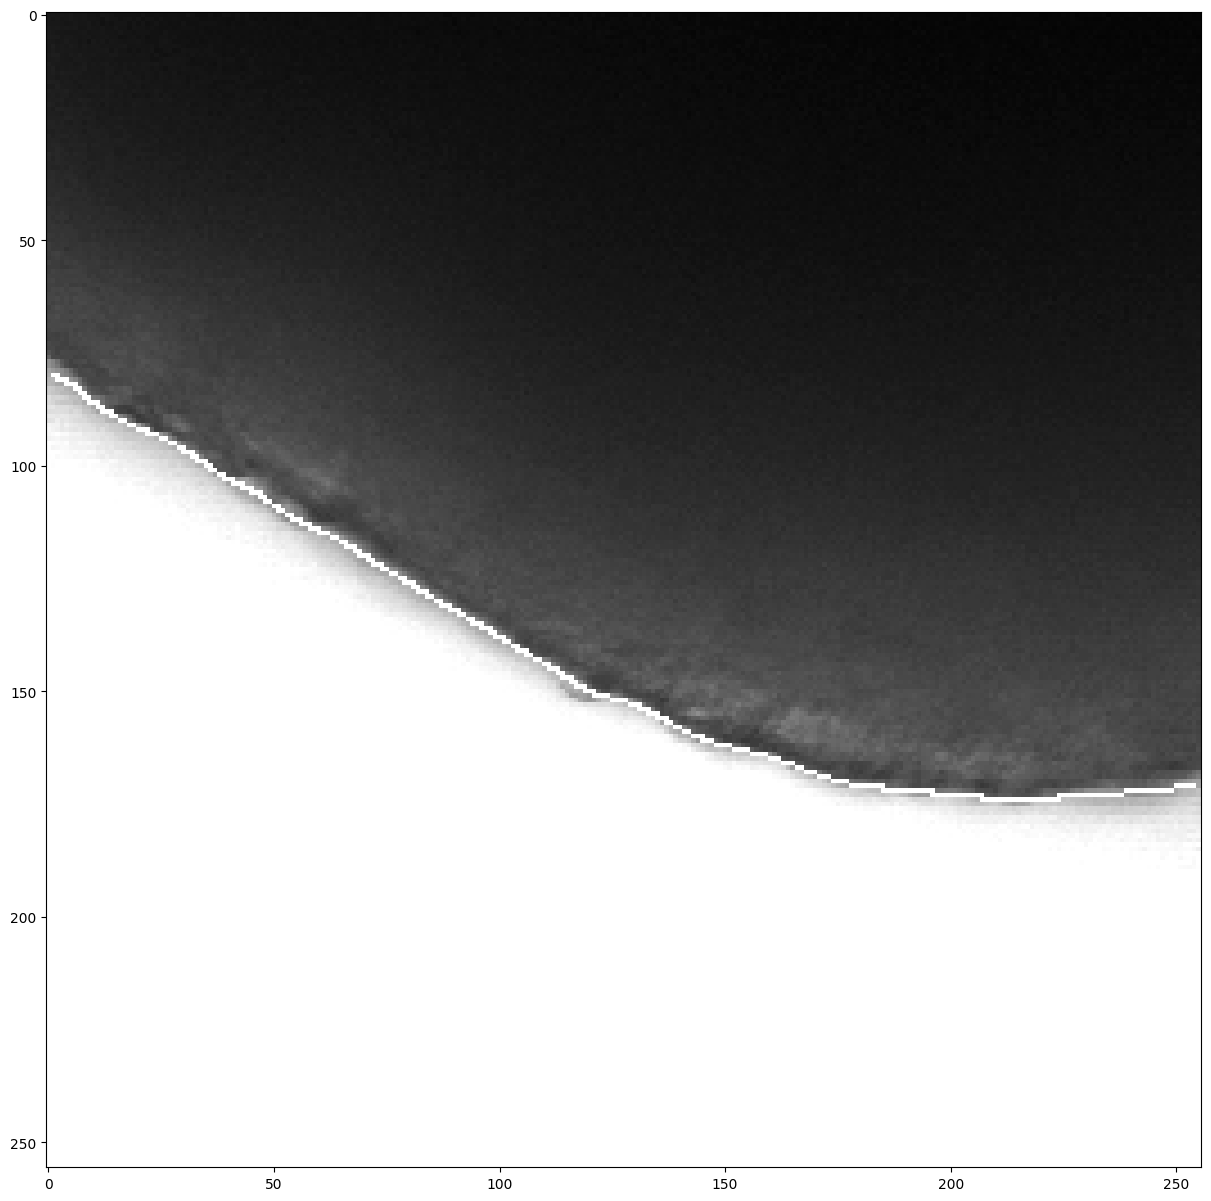

In [ ]:
#@markdown ###Step 7. Verifying threshold
#@markdown Execute this cell to have a look at the border we get with the automatic threshold.
#@markdown You can scroll through the video frames and change the default threshold to choose a
#@markdown value which will result in a good organoid/background seperation. The higher the threhsold the more lighter regions it will include.
class ImageSliceViewer3D:
    """
    ImageSliceViewer3D is for viewing volumetric image slices in jupyter or
    ipython notebooks.

    User can interactively change the slice plane selection for the image and
    the slice plane being viewed.

    Argumentss:
    Volume = 3D input image
    figsize = default(8,8), to set the size of the figure
    cmap = default('plasma'), string for the matplotlib colormap. You can find
    more matplotlib colormaps on the following link:
    https://matplotlib.org/users/colormaps.html

    """

    def __init__(self, volume_g, volume, threshold, figsize=(15,15), cmap='gray'):
        self.volume_g = volume_g
        self.volume = volume
        self.threshold = threshold
        self.figsize = figsize
        self.cmap = cmap
        self.v = [np.min(volume), np.max(volume)]

        # Call to view a slice within the selected slice plane
        ipyw.interact(self.change_thresh,
            t=ipyw.FloatSlider(value=self.threshold, min=0, max=1, step=0.01, continuous_update=False,
            description='Threshold:', readout_format='.2f'))

    def change_thresh(self, t):
      mask = self.volume_g > t
      self.img_copy = self.volume.copy()
      bar = ipyw.IntProgress(value=0, min=0, max=len(range(mask.shape[0])), description='Loading:',
                       bar_style='', # 'success', 'info', 'warning', 'danger' or ''
                       #style={'bar_color': 'maroon'},
                       #orientation='horizontal'
                       )
      display(bar)
      for i in range(mask.shape[0]):
        bar.value = i
        mask[i] = binary_opening(mask[i], disk(4))
        mask[i] = remove_small_objects(mask[i], min_size=400)
        mask[i] = feature.canny(mask[i], 3)
        img_temp = self.volume[i].copy()
        img_temp[mask[i]==1] = 255
        self.img_copy[i] = img_temp

      bar.bar_style = 'success'
      maxZ = self.volume.shape[0] - 1
      ipyw.interact(self.plot_slice,
          z=ipyw.IntSlider(min=0, max=maxZ, step=1, continuous_update=False,
          description='Time Frames:', layout=ipyw.Layout(width='100%')))


    def plot_slice(self, z):
        # Plot slice for the given plane and slice
        self.fig = plt.figure(figsize=self.figsize)
        plt.imshow(self.img_copy[z], cmap=plt.get_cmap(self.cmap),
            vmin=self.v[0], vmax=self.v[1])


ImageSliceViewer3D(img_gaussian, img_array, thresh)


In [ ]:
#@markdown ###Step 8. Setting of final threhsold for organoid border
#@markdown ####Set the threshold you chose in the previous step and **then** execute this cell.

thresh = 0.61 #@param {type:"number"}

# Open data info file
datafile = wig_ds.value
print('Opening file: ', datafile)
data_info = pd.read_excel(datafile)
df_columns = data_info.columns

#data_info = pd.read_excel('Contraction_videos_legend.xlsx')
# rename column if needed
if 'File_video name' in df_columns: data_info.rename(columns={'File_video name': 'Filename'}, inplace=True)
data_info['Filename'] = data_info['Filename'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])

# Add chosen threshold value to the info file
# data_info.insert(10,'Threshold', 'default') # only first time
data_info.loc[data_info['Filename'] == os.path.splitext(os.path.basename(wig.value))[0], 'Threshold'] = thresh
#data_info.to_excel("Contraction_videos_legend.xlsx", index=False)
data_info.to_excel(datafile, index=False)
# data_info

In [ ]:
#@markdown ###Step 9. Signal extraction

def extract_signal(img_array, thresh):

  border_size = []
  med_y = []
  rotated_masks = []
  num_frames = img_array.shape[0]
  print('Going to use threshold: ', thresh)

  # and go a second time over to extract signals
  for frame_id in range(num_frames):

    # extract border and sort pixels
    (x,y), _ = extract_border(img_array[frame_id], thresh)
    x, y = sort_border(x, y)
    # Rotate border so that is always parallel to x-axis
    theta = get_border_angle(x , y)
    mask = np.zeros(img_array[frame_id].shape, dtype=bool)
    mask[(x,y)] = True #size 256, 256
    mask_r = rotate(mask, theta, resize=True) # shape usually 305,305 but changes

    # store rotated image and length of border
    y = np.sort(np.where(mask_r)[1])
    dist_y = y[-1] - y[0]
    med_y.append(dist_y//2 + y[0])
    border_size.append(dist_y)
    rotated_masks.append(mask_r)

  # get minimum border length and where the border is minimized
  border_size = np.array(border_size)
  bbox_size = np.min(border_size)
  median_y = med_y[np.argmin(border_size)]

  if bbox_size%2==1: bbox_size-=1
  if bbox_size<100:
    print('The organoid is moving strongly in this video and the border is not enitrely visible in the scene in all frames.\n',
    'For this reason we will only export signals for 5 sub-regions of the border')
    subsample_regions = 5
  else:
    subsample_regions = 10
  distances = np.zeros((subsample_regions, num_frames))
  x_crop = 250

  del border_size
  del img_array
  del x
  del y
  del mask

  for frame_id in range(num_frames):

    mask_r = rotated_masks[frame_id]

    # Pad so we always have a fixed size image
    resize_size = (1024 - mask_r.shape[0], 512 - mask_r.shape[1])
    mask_r = np.pad(mask_r, ((resize_size[0]//2+mask_r.shape[0]%2, resize_size[0]//2), (resize_size[1]//2+mask_r.shape[1]%2, resize_size[1]//2)))

    # readjust median y to new img size
    median_yf = median_y + resize_size[1]//2+mask_r.shape[1]%2

    # Translate always relative to middle of image and around median of columns
    if frame_id==0:
      where_border = np.where(mask_r)
      mean_x = round(np.mean(where_border[0]))

    # crop edges of border so hopefully we are always including the same border points
    mask_r = mask_r[mean_x-x_crop:mean_x+x_crop, median_yf-bbox_size//2:median_yf+bbox_size//2]\

    # get new img size and size of subsampled regions
    new_height, new_width = mask_r.shape
    subsample_area = new_width//subsample_regions

    # get the average of coordinates in sub-region along the x-axis and subtract from average if frame0
    for i in range(subsample_regions):
      sub_area = mask_r[:,i*subsample_area:(i+1)*subsample_area]
      x_sub, _ = np.where(sub_area)
      distances[i, frame_id] = np.mean(x_sub)

  return distances, subsample_regions

distances, subsample_regions = extract_signal(img_array, thresh)

# save result in numpy file
for i in range(subsample_regions):
  distances[i, :] -= distances[i,0]
new_file = os.path.join(dst_filepath, Path(files[file_id]).stem+'.npy')
np.save(new_file, distances) #add dst_path

print(subsample_regions, ' signals were extracted from this video file and saved in: ', new_file)

d = np.load(new_file)
if np.any(np.isnan(d)):
 print('There may be a problem with this file, as it includes NaN values which can cause problems in the downstream analysis. Please check again that your threshold makes sense. If the problem persists please contact the Helmholtz AI consultants.')


Going to use threshold:  0.61
10  signals were extracted from this video file and saved in:  extracted_signals/230418_P1330_d50_KOLF_O1_a.npy


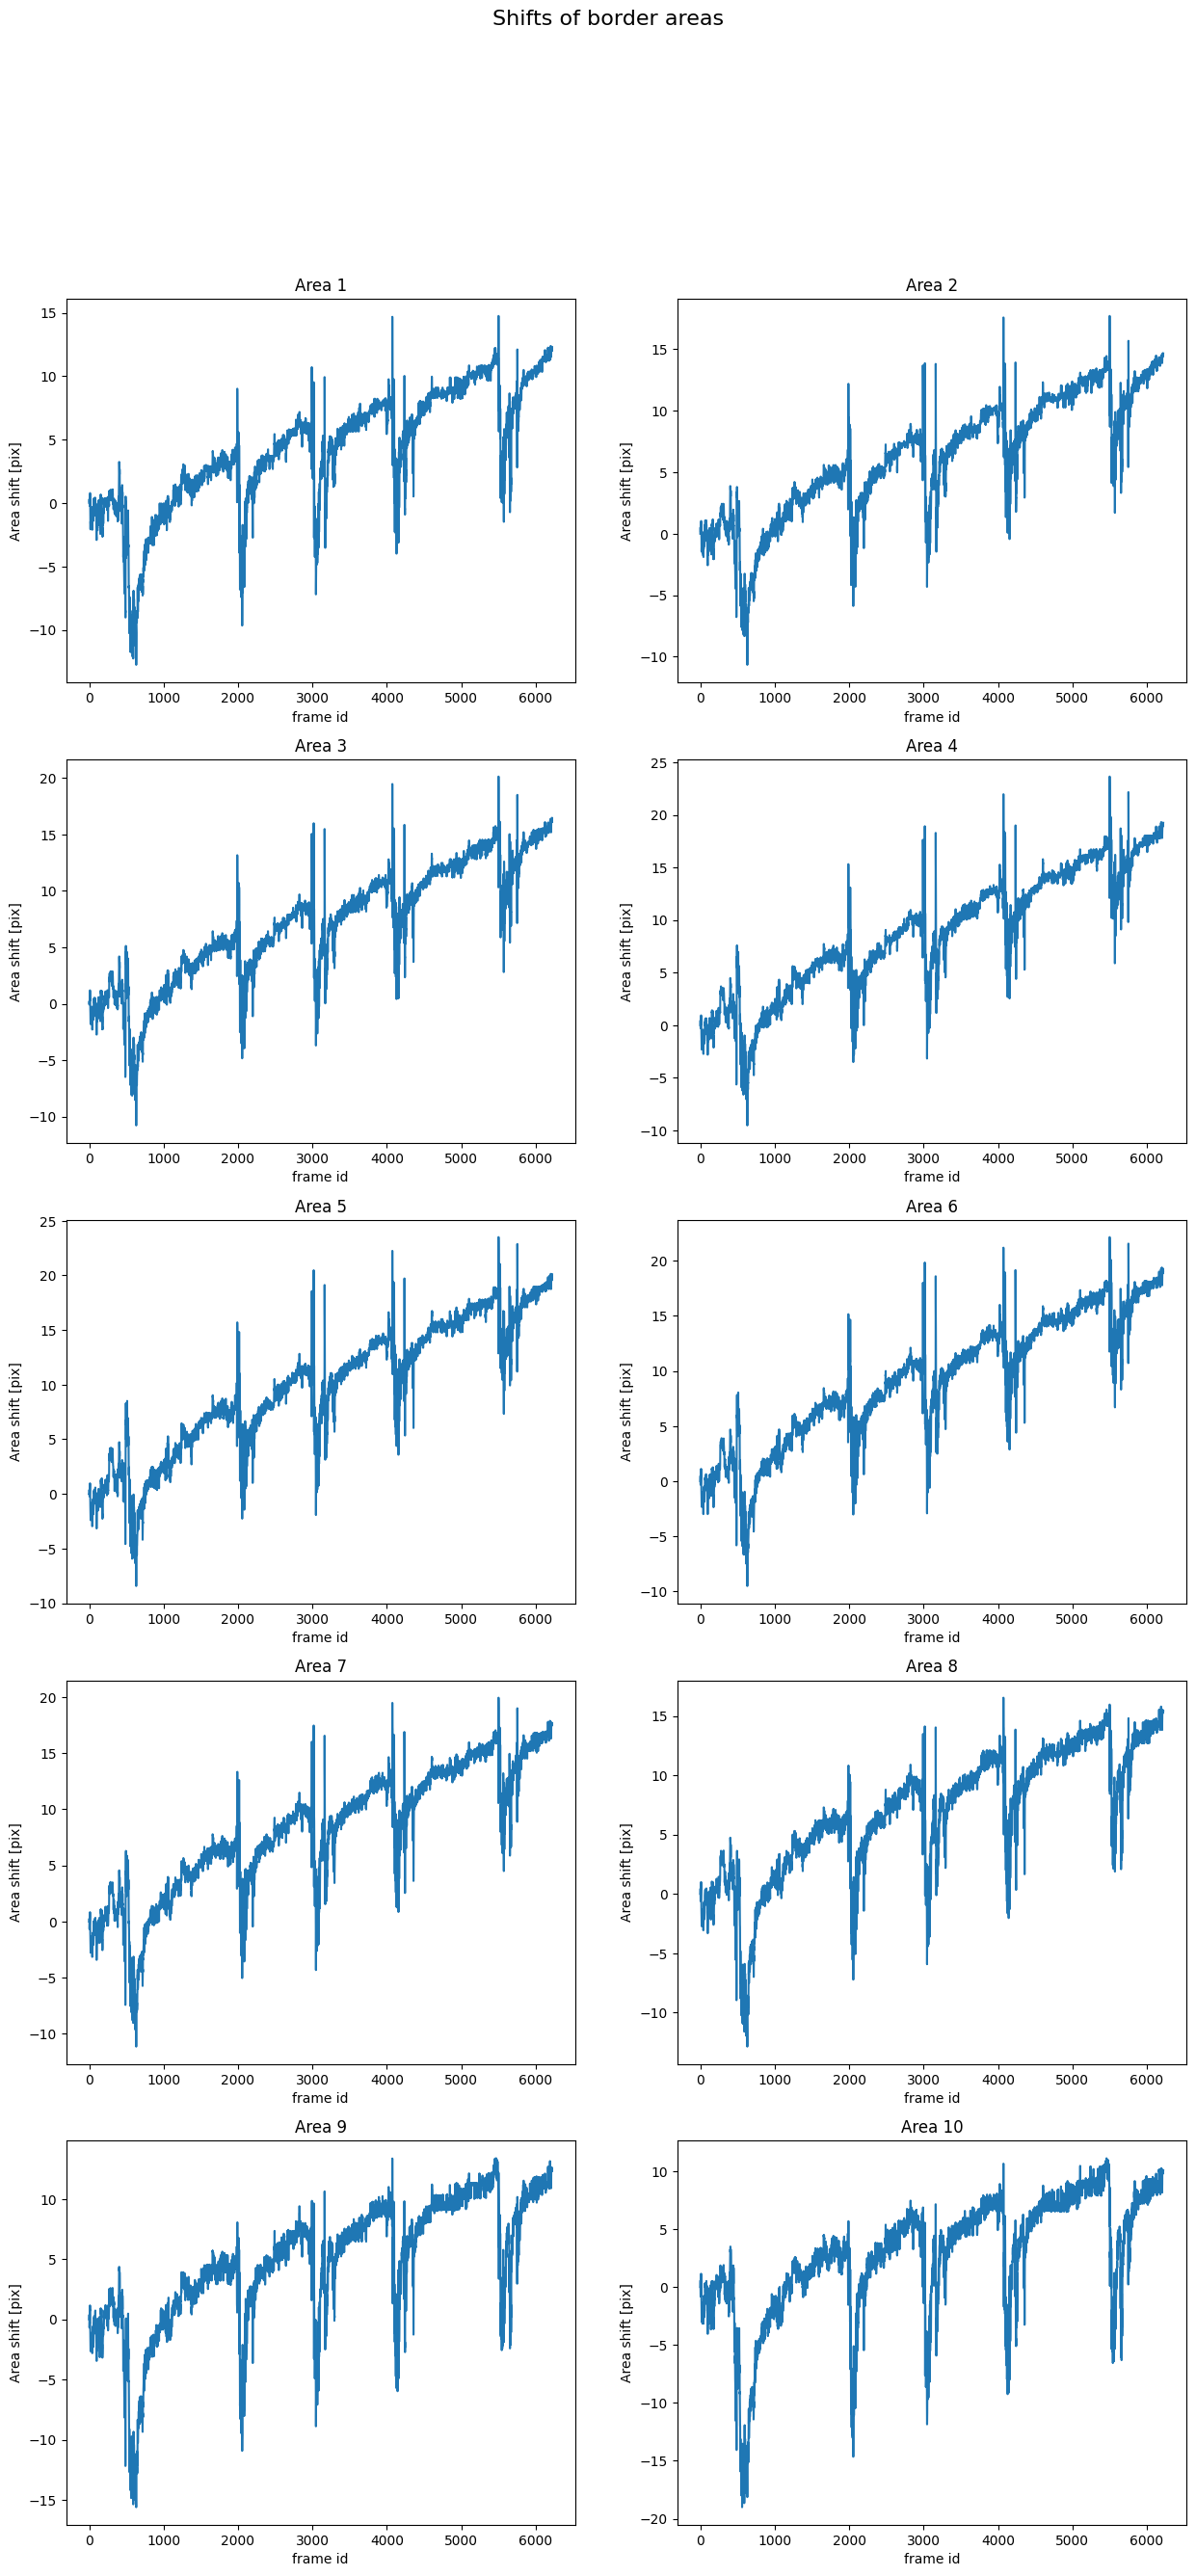

In [ ]:
#@markdown ###Step 10. Visualise results

#@markdown Run this cell to see the signals that were extracted. You can then return to Step 4 if you wish to work on a new organoid contraction video :)
if subsample_regions==10:
  cols=2
  fig, ax = plt.subplots(5, cols, figsize=(15,30))
  fig.suptitle('Shifts of border areas', fontsize=16)
  for i in range(subsample_regions):
    ax[i//2, i%2].plot(np.arange(distances.shape[1]), distances[i,:])
    ax[i//2, i%2].set_title('Area '+str(i+1), fontsize=12)
    ax[i//2, i%2].set_xlabel('frame id', fontsize=10)
    ax[i//2, i%2].set_ylabel('Area shift [pix]', fontsize=10)
else:
  fig, ax = plt.subplots(5, figsize=(15,30))
  fig.suptitle('Shifts of border areas', fontsize=16)
  for i in range(subsample_regions):
    ax[i].plot(np.arange(distances.shape[1]), distances[i,:])
    ax[i].set_title('Area '+str(i+1), fontsize=12)
    ax[i].set_xlabel('frame id', fontsize=10)
    ax[i].set_ylabel('Area shift [pix]', fontsize=10)